<a href="https://colab.research.google.com/github/AIML-Dept/Prajwal_T_Raj_1GA23AI034/blob/main/Tutorial_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install qiskit numpy matplotlib

Statevector after X gate: [0.+0.j 1.+0.j]


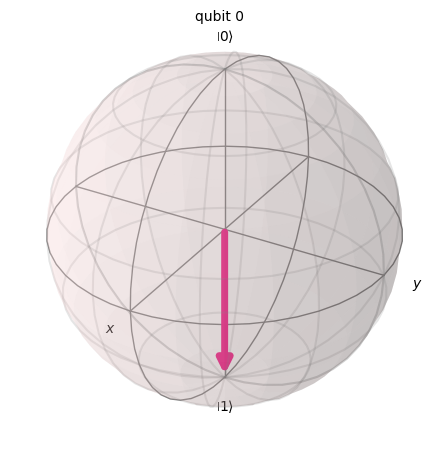

In [ ]:
# 1. Easy: The Pauli-X (NOT) Gate

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# 1. Create a 1-qubit circuit (starts in |0>)
qc_easy = QuantumCircuit(1)

# 2. Apply the X gate
qc_easy.x(0)

# 3. Get the statevector and print it
sv_easy = Statevector(qc_easy)
print("Statevector after X gate:", sv_easy.data)

# 4. Visualize on the Bloch sphere
plot_bloch_multivector(sv_easy)

Statevector after H and S gates: [0.707+0.j    0.   +0.707j]


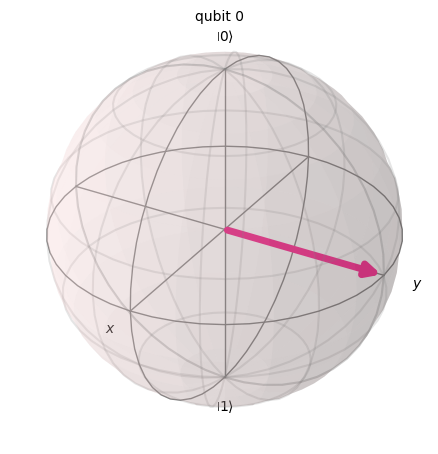

In [ ]:
# 2. Medium: Superposition and Phase Shift
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np

# 1. Create circuit
qc_medium = QuantumCircuit(1)

# 2. Apply H gate (Superposition) then S gate (Phase shift)
qc_medium.h(0)
qc_medium.s(0)

# 3. Get the statevector
sv_medium = Statevector(qc_medium)
print("Statevector after H and S gates:", np.round(sv_medium.data, 3))

# 4. Visualize
plot_bloch_multivector(sv_medium)

In [ ]:
# 3. Hard: 2-Qubit Superposition and Unity Verification

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

# 1. Create a 2-qubit circuit
qc_hard = QuantumCircuit(2)

# 2. Apply H gate to both qubits
qc_hard.h([0, 1])

# 3. Extract the statevector
sv_hard = Statevector(qc_hard)
amplitudes = sv_hard.data
print("2-Qubit Amplitudes:", np.round(amplitudes, 3))

# 4. Verify that the sum of squared amplitudes equals 1
sum_squared = sum(np.abs(amplitudes)**2)
print(f"Sum of squared amplitudes: {sum_squared}")

if np.isclose(sum_squared, 1.0):
    print("Verification passed: Probabilities sum to 1.")
else:
    print("Verification failed.")

2-Qubit Amplitudes: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Sum of squared amplitudes: 0.9999999999999996
Verification passed: Probabilities sum to 1.


Applying random phase error of 0.721 radians


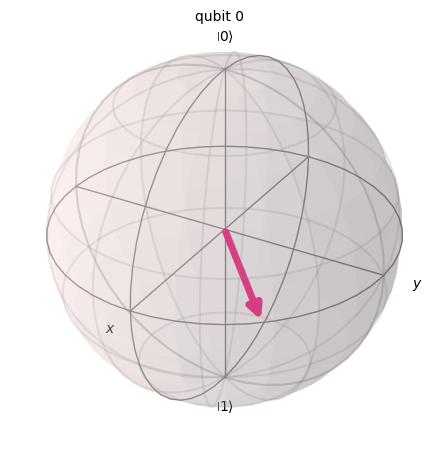

In [ ]:
# 4. Real-world: Simulating a Noisy Channel

import random
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# 1. Create circuit and put into superposition so phase is visible
qc_real = QuantumCircuit(1)
qc_real.h(0)

# 2. Generate a random small phase error (between 0 and 45 degrees)
random_error = random.uniform(0, np.pi/4)
print(f"Applying random phase error of {random_error:.3f} radians")

# 3. Apply the error using the P (Phase) gate
qc_real.p(random_error, 0)

# 4. Extract and plot
sv_real = Statevector(qc_real)
plot_bloch_multivector(sv_real)

Testing angles: Theta = 1.571, Phi = 0.785

Manual Vector: [0.707+0.j  0.5  +0.5j]
Qiskit Vector: [0.707+0.j  0.5  +0.5j]

Success: The manual math perfectly matches Qiskit's output!


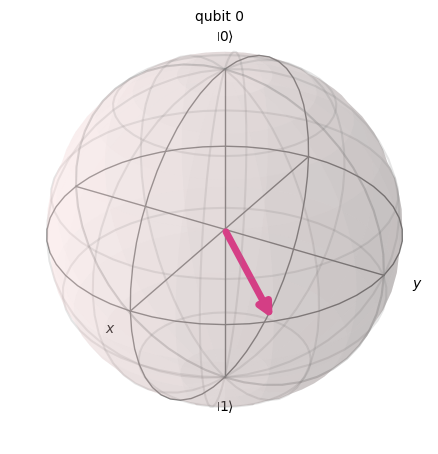

In [ ]:
# 5. Challenge: Arbitrary Rotation Validation

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

def arbitrary_qubit_plot(theta, phi):
    print(f"Testing angles: Theta = {theta:.3f}, Phi = {phi:.3f}\n")

    # 1. Manual Math Calculation
    # Formula: cos(theta/2)|0> + e^(i*phi) * sin(theta/2)|1>
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    manual_vector = np.array([alpha, beta])

    # 2. Qiskit Calculation
    qc_challenge = QuantumCircuit(1)
    # The U gate takes (theta, phi, lambda). We set lambda to 0.
    qc_challenge.u(theta, phi, 0, 0)
    qiskit_vector = Statevector(qc_challenge).data

    # 3. Comparison
    print("Manual Vector:", np.round(manual_vector, 3))
    print("Qiskit Vector:", np.round(qiskit_vector, 3))

    if np.allclose(manual_vector, qiskit_vector):
        print("\nSuccess: The manual math perfectly matches Qiskit's output!")
    else:
        print("\nError: Mismatch detected.")

    # 4. Plot the result (using the manual vector, though both are identical)
    return plot_bloch_multivector(Statevector(manual_vector))

# Test the function with some arbitrary angles (e.g., 90 degrees and 45 degrees)
arbitrary_qubit_plot(theta=np.pi/2, phi=np.pi/4)